In [1]:
import pandas as pd 
import requests
from bs4 import BeautifulSoup
from selenium import webdriver 
from selenium.webdriver.common.by import By
import time
import re

In [2]:
#Data Collection

In [3]:
Names=[]
Ratings=[]
Reviews=[]
    
for i in range(1,51):
    url = f"https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page={i}"
    r=requests.get(url)
    soup=BeautifulSoup(r.text,"html.parser")
    
    sub=soup.find_all("div",{"class":"new-review-card-container"})
    
    for i in sub:
        name=i.find("span",{"class":"review-author-name"})
        Names.append(name.text)
        
        #As there is no class for ratings, we need to look inside the ratings container to find the rating
        ratings_container=i.find("span",{"class":"star-count-container"})
        rating=ratings_container.find_all("span")[-1]
        Ratings.append(rating.text)
    
        review=i.find_all("div")[-1]
        Reviews.append(review.text.strip())

    print(url)

https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=1
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=2
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=3
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=4
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=5
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=6
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=7
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=8
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=9
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=10
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=11
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=12
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=13
https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page=14
https://www.flo

In [4]:
print(len(Names),len(Ratings),len(Reviews))
df=pd.DataFrame({
    "Customer Name":Names,
    "Customer Ratings":Ratings,
    "Customer Reviews":Reviews})

df.to_csv("flower_aura.csv")
df

500 500 500


,Customer Name,Customer Ratings,Customer Reviews
0,Ramesh Kumar pariyar,5,Great experience with FlowerAura.Delivery was ...
1,Anki M,5,Fresh flowers...liked it.
2,suraj chaunal,5,the flowers were fresh and colorful. TBH they ...
3,Bakiyalakshmi,5,"Very fresh flowers, delivered on time with bea..."
4,pulak.pal77,5,Roses quality is very nice.
...,...,...,...
495,Meghna Chaturvedi,5,The flowers arrived at time and they were fres...
496,jidhu joshua,5,It was amazing....!!!
497,Arun,4,Thanks for the flowers
498,prernasaini,5,Thank you so much


In [5]:
#Data Cleaning and Preprocessing

In [6]:
df[df["Customer Reviews"].duplicated()]

,Customer Name,Customer Ratings,Customer Reviews
49,Rahul GR,5,Good
57,sanjivsahdev,4,Good
68,divya2020honey,5,Good
76,P R Vasu,5,Good
84,sajid sheik,5,Good
...,...,...,...
484,Sanika,5,Excellent service
487,adeebatanzeem6,5,Best
488,Srinivasan.Nagarajan,5,good
489,Sumiit Bhatia,5,Good


In [7]:
df[df["Customer Name"].duplicated()]

,Customer Name,Customer Ratings,Customer Reviews
139,kiranthapa518,4,Good service
155,Abhishek,5,Excellent
253,Sagarika,5,Thank you so much ?
280,mmsinha17,5,
304,pooja,5,Very fresh & loved the presentation
368,Gauhar,5,Happy
377,vijayakarunathota718,5,Quality awesome
396,mmsinha17,5,Beautiful bouquet.\nThanks ?
419,Vikram,5,Marvelous
454,krishnamurthy,5,Timely Delivery and very good packing


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Customer Reviews"] = df["Customer Reviews"].str.strip()
df = df[df["Customer Reviews"] != ""].copy()

In [10]:
df.shape


(484, 3)

In [11]:
df['Customer Ratings'].str.strip()
df[df['Customer Ratings']!=""]

,Customer Name,Customer Ratings,Customer Reviews
0,Ramesh Kumar pariyar,5,Great experience with FlowerAura.Delivery was ...
1,Anki M,5,Fresh flowers...liked it.
2,suraj chaunal,5,the flowers were fresh and colorful. TBH they ...
3,Bakiyalakshmi,5,"Very fresh flowers, delivered on time with bea..."
4,pulak.pal77,5,Roses quality is very nice.
...,...,...,...
495,Meghna Chaturvedi,5,The flowers arrived at time and they were fres...
496,jidhu joshua,5,It was amazing....!!!
497,Arun,4,Thanks for the flowers
498,prernasaini,5,Thank you so much


In [12]:
df['Customer Reviews']=df['Customer Reviews'].str.lower()

In [13]:
df["Customer Reviews"] = df["Customer Reviews"].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))
df["Customer Reviews"] = df["Customer Reviews"].str.replace(r'\s+', ' ', regex=True).str.strip()

In [14]:
import nltk

In [15]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df["Cleaned_Review"] = df["Customer Reviews"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

In [16]:
df

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...
1,Anki M,5,fresh flowersliked it,fresh flowersliked
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flowers fresh colorful tbh better expected thanks
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flowers delivered time beautiful packagi...
4,pulak.pal77,5,roses quality is very nice,roses quality nice
...,...,...,...,...
495,Meghna Chaturvedi,5,the flowers arrived at time and they were fres...,flowers arrived time fresh beautifully arranged
496,jidhu joshua,5,it was amazing,amazing
497,Arun,4,thanks for the flowers,thanks flowers
498,prernasaini,5,thank you so much,thank much


In [17]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
df["Cleaned_Review"] = df["Cleaned_Review"].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

In [18]:
df


,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...
1,Anki M,5,fresh flowersliked it,fresh flowersliked
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...
4,pulak.pal77,5,roses quality is very nice,rose quality nice
...,...,...,...,...
495,Meghna Chaturvedi,5,the flowers arrived at time and they were fres...,flower arrived time fresh beautifully arranged
496,jidhu joshua,5,it was amazing,amazing
497,Arun,4,thanks for the flowers,thanks flower
498,prernasaini,5,thank you so much,thank much


In [19]:
#Sentiment Analysis

In [20]:
from textblob import TextBlob

In [21]:
def pol(value):
    blob=TextBlob(value)
    return blob.sentiment.polarity
df['Polarity']=df['Cleaned_Review'].apply(pol)
df

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review,Polarity
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...,0.452381
1,Anki M,5,fresh flowersliked it,fresh flowersliked,0.300000
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks,0.240000
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...,0.502381
4,pulak.pal77,5,roses quality is very nice,rose quality nice,0.600000
...,...,...,...,...,...
495,Meghna Chaturvedi,5,the flowers arrived at time and they were fres...,flower arrived time fresh beautifully arranged,0.575000
496,jidhu joshua,5,it was amazing,amazing,0.600000
497,Arun,4,thanks for the flowers,thanks flower,0.200000
498,prernasaini,5,thank you so much,thank much,0.200000


In [22]:
def rate_pol(value):
    if value>=0.1:
        return "positive"
    else:
        return "negative"
df["Sentiment"]=df["Polarity"].apply(rate_pol)
df

,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review,Polarity,Sentiment
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...,0.452381,positive
1,Anki M,5,fresh flowersliked it,fresh flowersliked,0.300000,positive
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks,0.240000,positive
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...,0.502381,positive
4,pulak.pal77,5,roses quality is very nice,rose quality nice,0.600000,positive
...,...,...,...,...,...,...
495,Meghna Chaturvedi,5,the flowers arrived at time and they were fres...,flower arrived time fresh beautifully arranged,0.575000,positive
496,jidhu joshua,5,it was amazing,amazing,0.600000,positive
497,Arun,4,thanks for the flowers,thanks flower,0.200000,positive
498,prernasaini,5,thank you so much,thank much,0.200000,positive


In [23]:
#Data visualization

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


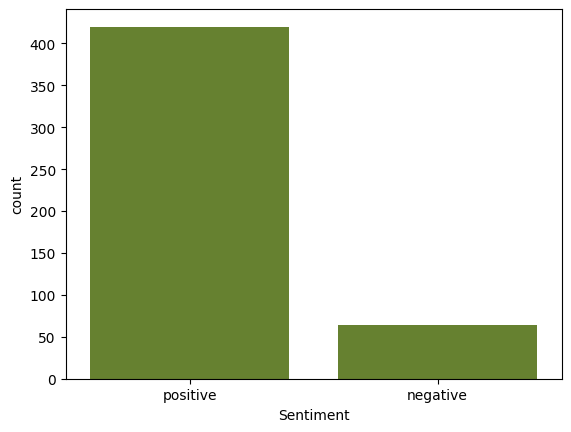

In [25]:
sns.countplot(data=df,x=df['Sentiment'],color='olivedrab')
plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 484 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer Name     484 non-null    object 
 1   Customer Ratings  484 non-null    object 
 2   Customer Reviews  484 non-null    object 
 3   Cleaned_Review    484 non-null    object 
 4   Polarity          484 non-null    float64
 5   Sentiment         484 non-null    object 
dtypes: float64(1), object(5)
memory usage: 26.5+ KB


Correlation: -0.007135212725726403


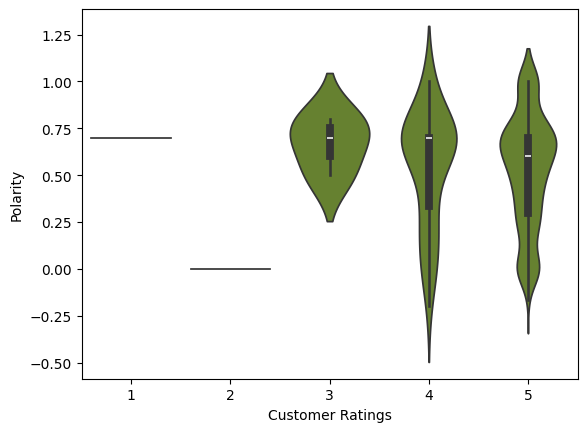

In [27]:
df['Customer Ratings'] = df['Customer Ratings'].astype(int)

correlation = df['Customer Ratings'].corr(df['Polarity'])
print("Correlation:", correlation)
sns.violinplot(x='Customer Ratings', y='Polarity', data=df, color='olivedrab')
plt.show()

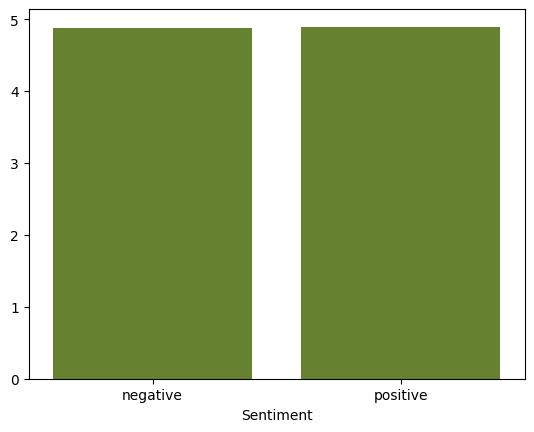

In [28]:
avg_rating=df.groupby('Sentiment')['Customer Ratings'].mean()
sns.barplot(x=avg_rating.index, y=avg_rating.values, color='olivedrab')
plt.show()

In [29]:
#High ratings are not consistently more positive

In [30]:
from wordcloud import WordCloud

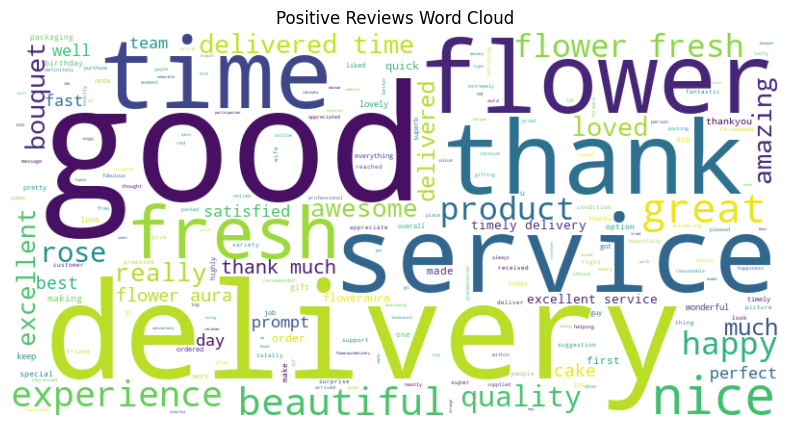

In [31]:
positive_reviews = df[df['Sentiment'] == 'positive']['Cleaned_Review']
positive_text = " ".join(positive_reviews)

wc_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_positive, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

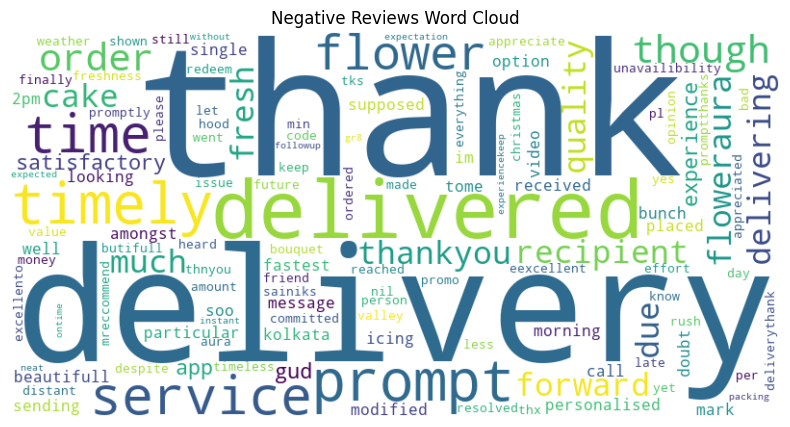

In [32]:
negative_reviews = df[df['Sentiment'] == 'negative']['Cleaned_Review']
negative_text = " ".join(negative_reviews)
wc_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_negative, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

In [33]:
df.head()


,Customer Name,Customer Ratings,Customer Reviews,Cleaned_Review,Polarity,Sentiment
0,Ramesh Kumar pariyar,5,great experience with flowerauradelivery was o...,great experience flowerauradelivery time produ...,0.452381,positive
1,Anki M,5,fresh flowersliked it,fresh flowersliked,0.300000,positive
2,suraj chaunal,5,the flowers were fresh and colorful tbh they w...,flower fresh colorful tbh better expected thanks,0.240000,positive
3,Bakiyalakshmi,5,very fresh flowers delivered on time with beau...,fresh flower delivered time beautiful packagin...,0.502381,positive
4,pulak.pal77,5,roses quality is very nice,rose quality nice,0.600000,positive


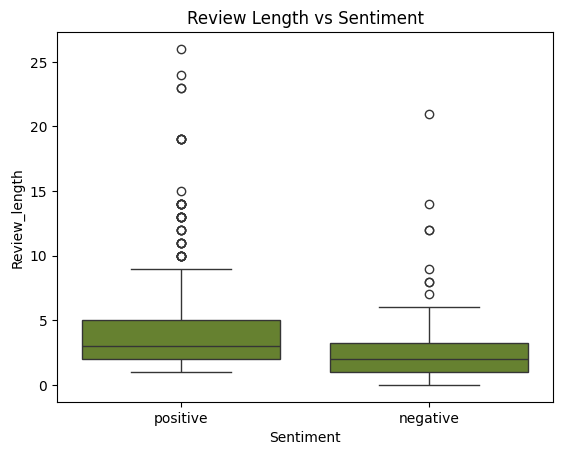

In [34]:
df['Review_length']=df['Cleaned_Review'].apply(lambda x: len(x.split()))
sentiment_wise=df.groupby('Sentiment')['Review_length'].mean()
sns.boxplot(x=df['Sentiment'],y=df['Review_length'],color='olivedrab')
plt.title("Review Length vs Sentiment")
plt.show()

In [35]:
''' Positive reviews have a wider spread where as negative reviews are more compact.
    There are more outliers i.e longer reviews in case of positive reviews.'''

' Positive reviews have a wider spread where as negative reviews are more compact.\n    There are more outliers i.e longer reviews in case of positive reviews.'

In [36]:
#Reporting

In [37]:
'''1. Data Collection Overview- The dataset was collected using web scraping techniques from the FlowerAura website. Customer reviews were extracted
      individually, including the customer name, review text, and ratings provided for each product. The data was collected across multiple pages.

      Data Cleaning Overview- There were no null values present in the customer name, ratings, or review columns. Duplicate rows were checked across 
      all columns, and no exact duplicate records were found.Although some customer names and reviews appeared multiple times, these were retained as
      valid entries. Repeated customer names indicate that the same customer may have provided multiple reviews, while identical reviews across
      different entries may represent similar feedback from different customers.'''

'1. Data Collection Overview- The dataset was collected using web scraping techniques from the FlowerAura website. Customer reviews were extracted\n      individually, including the customer name, review text, and ratings provided for each product. The data was collected across multiple pages.\n\n      Data Cleaning Overview- There were no null values present in the customer name, ratings, or review columns. Duplicate rows were checked across \n      all columns, and no exact duplicate records were found.Although some customer names and reviews appeared multiple times, these were retained as\n      valid entries. Repeated customer names indicate that the same customer may have provided multiple reviews, while identical reviews across\n      different entries may represent similar feedback from different customers.'

In [38]:
'''2. Sentiment Analysis Results
      The sentiment distribution is highly skewed, with positive reviews exceeding 400, while negative reviews range between 50–100, indicating 
      overall positive customer feedback. The correlation between customer ratings and sentiment polarity is approximately -0.007, showing no 
      significant -relationship between the two. Additionally, the average sentiment across different rating levels shows minimal variation.'''
      

'2. Sentiment Analysis Results\n      The sentiment distribution is highly skewed, with positive reviews exceeding 400, while negative reviews range between 50–100, indicating \n      overall positive customer feedback. The correlation between customer ratings and sentiment polarity is approximately -0.007, showing no \n      significant -relationship between the two. Additionally, the average sentiment across different rating levels shows minimal variation.'

In [39]:
'''3. The sentiment analysis reveals that customer feedback is predominantly positive, indicating overall satisfaction. From the word cloud analysis,
      positive highlights include terms such as “good,” “service,” “delivery,” “beautiful,” and “fresh,” suggesting that customers appreciate product
      quality, timely delivery, and overall service experience.

      On the other hand, the negative reviews highlight issues related to “delivery,” “time,” “order,” and “service,” indicating concerns such as 
      delays, order handling, and service inefficiencies.'''

'3. The sentiment analysis reveals that customer feedback is predominantly positive, indicating overall satisfaction. From the word cloud analysis,\n      positive highlights include terms such as “good,” “service,” “delivery,” “beautiful,” and “fresh,” suggesting that customers appreciate product\n      quality, timely delivery, and overall service experience.\n\n      On the other hand, the negative reviews highlight issues related to “delivery,” “time,” “order,” and “service,” indicating concerns such as \n      delays, order handling, and service inefficiencies.'

In [40]:
'''4. Recommendations
    While customers are largely satisfied with product quality and overall experience, operational aspects such as delivery, order handling, and 
    service responsiveness present key opportunities for improvement.'''

'4. Recommendations\n    While customers are largely satisfied with product quality and overall experience, operational aspects such as delivery, order handling, and \n    service responsiveness present key opportunities for improvement.'